<a href="https://colab.research.google.com/github/tialedencan/Basics-of-data-analysis/blob/main/feritai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/marinbenc/cnn_workshop_feritai/edit/main/feritai.ipynb)

# Convolutional Neural Networks: Looking Inside the Black Box

*Workshop at FERIT.AIxperience 2025, 12. 2. 2025.*

In [2]:
!rm -rf clone && git clone https://github.com/marinbenc/cnn_workshop_feritai.git clone && cp -a clone/. .

Cloning into 'clone'...
remote: Enumerating objects: 538, done.
remote: Counting objects: 100% (538/538), done.
remote: Compressing objects: 100% (528/528), done.
remote: Total 538 (delta 12), reused 529 (delta 6), pack-reused 0 (from 0)
Receiving objects: 100% (538/538), 28.89 MiB | 5.53 MiB/s, done.
Resolving deltas: 100% (12/12), done.
Updating files: 100% (507/507), done.


In [3]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import os
import utils
import torch
import torch.nn as nn
import torch.optim as optim
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
import glob
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np
import torchvision
import torchvision.transforms as transforms

torch.manual_seed(1)

In [4]:
X, labels = utils.train_dataset_grades(1000)
X[0]

tensor([7.5763, 2.5818, 4.0735])

In [5]:
class SimpleNet(nn.Module):
  def __init__(self):
    super(SimpleNet, self).__init__()
    self.fc1 = nn.Linear(3,2)
    self.relu = nn.ReLU()
    self.fc2 = nn.Linear(2,1)

  def forward(self, x):
    x = self.fc1(x)
    x = self.relu(x)
    x = self.fc2(x)
    return x

In [6]:
model = SimpleNet()
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr = 0.01)
num_epochs = 100

X, labels = utils.train_dataset_grades(1000)

for epoch in range(num_epochs):
  outputs = model(X)
  loss = criterion(outputs, labels)

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  if(epoch + 1) % 10 == 0:
    print(loss)

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/loss.py:608: UserWarning: Using a target size (torch.Size([1000])) that is different to the input size (torch.Size([1000, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


tensor(0.3358, grad_fn=<MseLossBackward0>)
tensor(0.2861, grad_fn=<MseLossBackward0>)
tensor(0.2632, grad_fn=<MseLossBackward0>)
tensor(0.2498, grad_fn=<MseLossBackward0>)
tensor(0.2412, grad_fn=<MseLossBackward0>)
tensor(0.2353, grad_fn=<MseLossBackward0>)
tensor(0.2309, grad_fn=<MseLossBackward0>)
tensor(0.2275, grad_fn=<MseLossBackward0>)
tensor(0.2247, grad_fn=<MseLossBackward0>)
tensor(0.2222, grad_fn=<MseLossBackward0>)


In [7]:
hours_studied = 2
grade = 5
absences = 10

input = torch.tensor([hours_studied, grade, absences], dtype = torch.float32)
output = model(input)
output

tensor([1.0130], grad_fn=<ViewBackward0>)

5


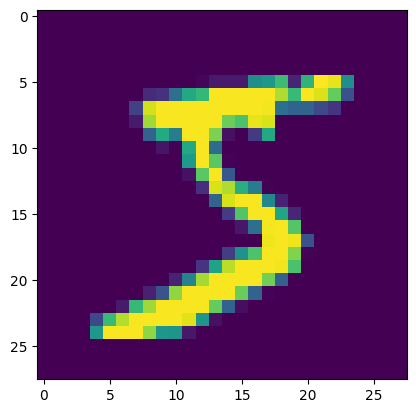

In [8]:
train_dataset = utils.get_mnist_dataset_train()
img, label = train_dataset[0]
plt.imshow(img.squeeze())
print(label)

In [9]:
# fc:  784 -> 256
#relu
# fc: 256 -> 10

class SimpleNet(nn.Module):
   def __init__(self):
    super(SimpleNet, self).__init__()
    self.fc1 = nn.Linear(784,256)
    self.relu = nn.ReLU()
    self.fc2 = nn.Linear(256,10)

   def forward(self, x):
    x = x.view(x.size(0), -1) # 28x28 -> 784 - sliku pretvori u vektor duljine 784
    x = self.fc1(x)
    x = self.relu(x)
    x = self.fc2(x)
    return x



In [10]:
model = SimpleNet()

criterion = nn.CrossEntropyLoss()


In [11]:
dataset = utils.get_mnist_dataset_train()
train_loader = DataLoader(dataset, batch_size=32, shuffle = True)

for img, label in train_loader:
  print(img.shape)
  print(label.shape)
  break

torch.Size([32, 1, 28, 28])
torch.Size([32])


In [13]:
model = SimpleNet()

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr = 0.01)

num_epochs = 10

for epoch in range(num_epochs):
  correct = 0
  total = 0

  for img, label in train_loader:
    outputs = model(img) #[0.1, 0.3, 0.9, 0.1...]
    loss = criterion(outputs, label)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    total += len(label)
    correct_predictions = torch.argmax(outputs, dim = 1)==label
    correct += torch.sum(correct_predictions)

  accuracy = correct/total
  print(accuracy)


tensor(0.8135)
tensor(0.8975)
tensor(0.9096)
tensor(0.9190)
tensor(0.9255)
tensor(0.9312)
tensor(0.9363)
tensor(0.9407)
tensor(0.9444)
tensor(0.9485)


In [14]:
class CNN(nn.Module):
  def __delattr__(self, name):
    super(CNN, self).__init__()
    self.conv1 = nn.Conv2d(1, 16, kernel_size = 3, stride = 1, padding = 1) #1 crna slika , 16 konvolucija
    self.relu = nn.ReLU()
    self.conv2 = nn.Conv2d(16, 32, kernel_size = 3, stride = 1, padding = 1) # dubina 32

    self.pool = nn.MaxPool2d(kernel_size = 2, stride = 2) #smanji velicinu slike za 2
    self.fc1 = nn.Linear(32*7*7, 128)
    self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
      x = self.conv1(x) # 1 X 28 X 28 -> 16 X 28 X 28
      x = self.relu(x)
      x = self.pool(x) # 16 X 28 X 28 -> 16 X 14 X 14

      x = self.conv2(x) # 16 X 14 X 14 -> 32 X 14 X 14
      x = self.relu(x)
      x = self.pool(x) # 32 X 14 X 14 -> 32 X 7 X 7

      x = x.view(x.size(0), -1) #32 X 7 X 7 -> 32*7*7 (VEKTOR BROJEVA)
      x = self.fc1(x)
      x = self.relu(x)
      x = self.fc2(x)
      return x


In [15]:
model = CNN()

model.load_state_dict(torch.load('cnn_mnist.pt'))
#criterion = nn.CrossEntropyLoss()
#optimizer = optim.SGD(model.parameters(), lr = 0.01)

num_epochs = 10

for epoch in range(num_epochs):
  correct = 0
  total = 0

  for img, label in train_loader:
    outputs = model(img) #[0.1, 0.3, 0.9, 0.1...]
    loss = criterion(outputs, label)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    total += len(label)
    correct_predictions = torch.argmax(outputs, dim = 1)==label
    correct += torch.sum(correct_predictions)

  accuracy = correct/total
  print(accuracy)


ValueError: optimizer got an empty parameter list

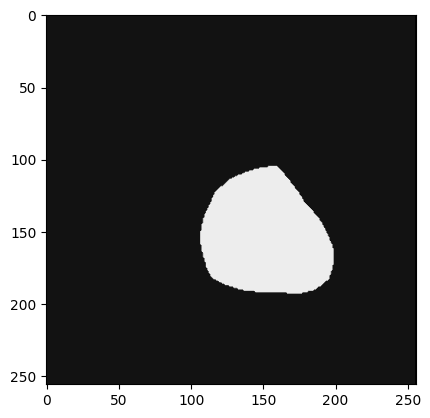

In [24]:
image_path = 'data/images/JPCLN001.jpg'
label_path = 'data/labels/JPCLN001.png'

xray_image = cv.imread(image_path, cv.IMREAD_GRAYSCALE)
label_image = cv.imread(label_path, cv.IMREAD_GRAYSCALE)


plt.imshow(xray_image)
plt.imshow(label_image, cmap = 'gray')
plt.contourf(label_image, cmap = 'gray')


In [34]:
class XRayDataset(Dataset):
  def __init__(self):
    images_dir = 'data/images'
    labels_dir = 'data/labels'

    self.image_path = utils.get_image_files_in_folder(images_dir)
    self.label_path = utils.get_image_files_in_folder(labels_dir)

    def __len__(self):
     return len(self.image_path)

    def __getitem__(self, index):
      image = cv.imread(self.image_path[index], cv.IMREAD_GRAYSCALE)
      label = cv.imread(self.label_path[index], cv.IMREAD_GRAYSCALE)

      image_tensor = utils.image_to_tensor(image) #torch.from_numpy(image).unsqueeze(0).float()
      label_tensor = utils.image_to_tensor(label)

      return image_tensor, label_tensor




In [35]:
dataset = XRayDataset()
img, label = dataset[0]
plt.imshow(img.squeeze())
plt.contour(label.squeeze, colors = 'red')

TypeError: 'XRayDataset' object is not subscriptable

In [ ]:
class FCN(nn.Module):
  def __init__(self):
    super(FCN, self).__init__()

    self.layer1 = nn.Sequential(
        nn.Conv2d(1, 64, kernel_size = 3, padding = 1),
        nn.BatchNorm2d(64),
        nn.ReLU(),
    )

    self.layer2 = nn.Sequential(
        nn.Conv2d(64, 64, kernel_size = 3, padding = 1),
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.MaxPool2d(2)
    )

    self.layer3 = nn.Sequential(
        nn.Conv2d(64, 128, kernel_size = 3, padding = 1),
        nn.BatchNorm2d(128),
        nn.ReLU(),
    )
    self.layer4 = nn.Sequential(
        nn.Conv2d(128, 128, kernel_size = 3, padding = 1),
        nn.BatchNorm2d(128),
        nn.ReLU(),
        nn.MaxPool2d(2)
    )

    self.layer5 = nn.Sequential(
        nn.Conv2d(128, 256, kernel_size = 3, padding = 1),
        nn.BatchNorm2d(256),
        nn.ReLU(),
    )

    self.seg_map = nn.Conv2d(256, 1, kernel_size = 1) # nakon ovog sloja je jedann kanal

    self.up = nn.ConvTranspose2d(1, 1, kernel_size = 2, stride = 2)

  def forward(self, x):
    x = self.layer1(x)
    x = self.layer2(x)
    x = self.layer3(x)
    x = self.layer4(x)
    x = self.layer5(x)
    x = self.seg_map(x)
    x = self.up(x)
    x = self.up(x)
    x = nn.Sigmoid()(x)
    return x

In [ ]:
model = FCN()
dataset = XRayDataset()
train_loader = DataLoader(dataset, batch_size=32, shuffle = True)

epochs = 10
optimizer = optim.Adam(model.parameters(), lr = 0.001)

for epoch in range(epochs):
  epoch_loss = 0
  for img, label in train_loader:
    outputs = model(img)
    loss = utils.dice_loss(outputs, label)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    epoch_loss += loss.item()

  print(epoch_loss/ len(train_loader))